In [7]:
import os
import numpy as np
import imageio.v2 as imageio
from typing import Tuple, Optional, Dict # Keep Dict for consistent return type signature, even if None

# --- Simplified JP2 Loading Function (Imageio only) ---
def load_jp2_data_imageio(channel_dir: str) -> Tuple[Optional[np.ndarray], Optional[Dict]]:
    """Loads JP2 data using Imageio from a single channel directory.
       Metadata will always be None.
    """
    jp2_files = [f for f in os.listdir(channel_dir) if f.endswith(".jp2")]
    if not jp2_files:
        print(f"Warning: No JP2 files found in: {channel_dir}")
        return None, None
    jp2_path = os.path.join(channel_dir, jp2_files[0])
    print(f"Attempting to load JP2 with Imageio: {jp2_path}")

    data = None
    try:
        data = imageio.imread(jp2_path)
        print("Imageio loaded successfully.")
        print(f"  Data shape: {data.shape}, dtype: {data.dtype}")
    except Exception as e_imgio:
        print(f"Imageio failed: {e_imgio}")
        return None, None # Failed to load

    # Return data and None for metadata, matching the original function signature
    return data, None

Standard SDO/AIA Properties: Full-resolution SDO/AIA images (like the ones often saved as JP2 or FITS) are typically 4096x4096 pixels.
Known Angular Size: The Sun's apparent radius as seen from Earth varies slightly, but it's usually around 960 arcseconds (rsun_obs in FITS metadata).
Known Pixel Scale: The resolution or pixel scale for SDO/AIA is very close to 0.6 arcseconds per pixel (cdelt1 in FITS metadata).
Calculation: If you divide the Sun's angular radius by the pixel scale, you get the radius in pixels: Radius (pixels) = Angular Radius (arcsec) / Pixel Scale (arcsec/pixel) ≈ 960 / 0.6 = 1600 pixels.
Common Practice: Because of this, 1600 pixels is a widely used and generally accurate radius for creating masks on 4096x4096 SDO/AIA images when you don't have, or don't trust, the specific metadata for that image (which is often the case with JP2).

Attempting to load JP2 with Imageio: /home/alyonaivanova/personal/SOLAR/Data/sdo_jp2/aia_1600/2017_09_10__16_00_38_12__SDO_AIA_AIA_1600.jp2
Imageio loaded successfully.
  Data shape: (4096, 4096), dtype: uint8
Creating mask for image of size: 4096x4096
Creating mask using fixed radius: 1600
  --> Fixed radius mask generated.
Mask created. Number of masked pixels (True): 8042349


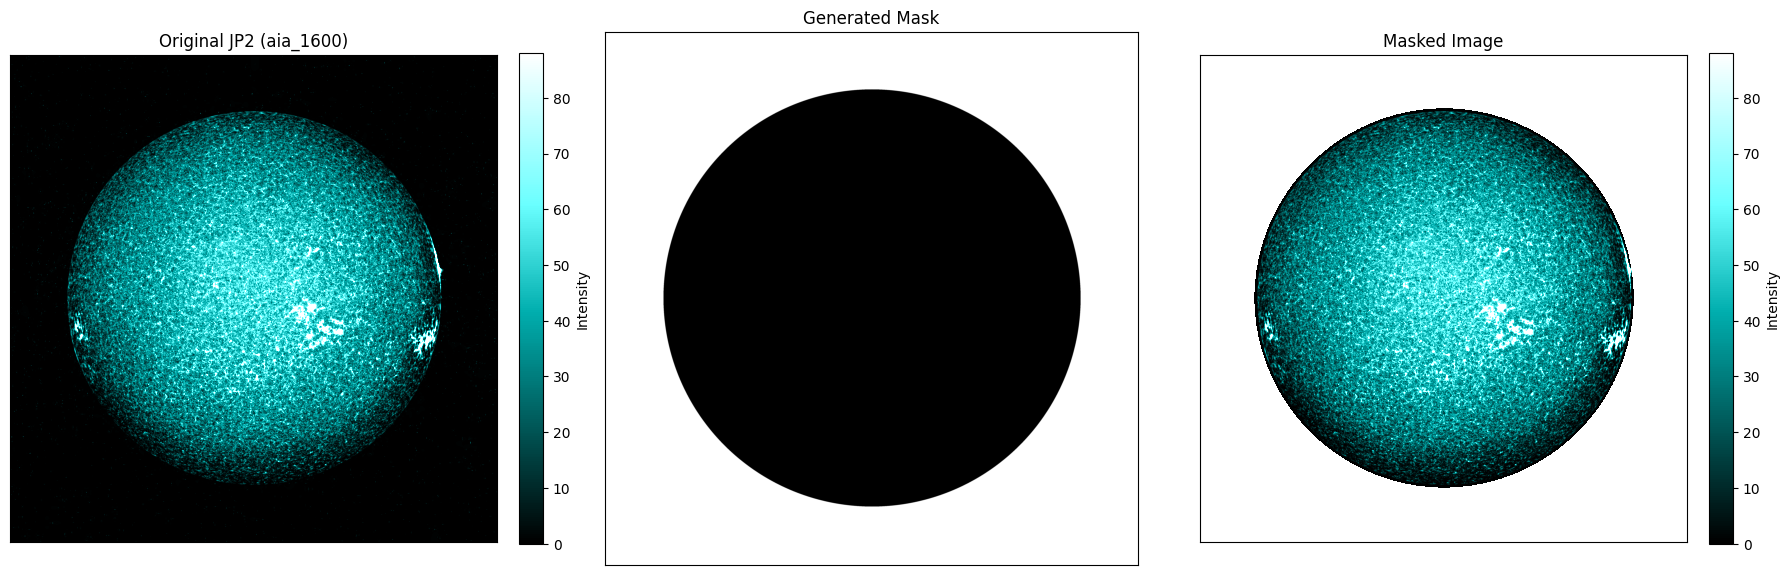

In [8]:
# --- Notebook Execution (using simplified loader) ---

# 1. Define Data Path
base_data_dir = '/home/alyonaivanova/personal/SOLAR/Data/sdo_jp2' # <<< ADJUST THIS PATH if needed
test_channel = 'aia_1600' # <<< Choose a channel to test
channel_dir = os.path.join(base_data_dir, test_channel)

# 2. Load Data using the Imageio-only function
jp2_data, jp2_metadata = load_jp2_data_imageio(channel_dir) # jp2_metadata will be None

# 3. Create Mask (if data loaded)
jp2_mask = None
if jp2_data is not None:
    # We know metadata is None, so the function will use the fixed radius
    jp2_mask = create_circular_mask_jp2(jp2_data, metadata=None, fixed_radius_pixels=1600)

# 4. Visualize
if jp2_data is not None and jp2_mask is not None:
    # Apply mask for visualization (set outside pixels to NaN or a fixed value)
    masked_jp2_data = jp2_data.astype(float).copy() # Work with float copy
    masked_jp2_data[~jp2_mask] = np.nan # Set outside to NaN

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Determine good intensity limits for display (avoid extremes)
    vmin = np.nanpercentile(jp2_data, 1)
    vmax = np.nanpercentile(jp2_data, 99)

    # Original Image
    im0 = axes[0].imshow(jp2_data, cmap='sdoaia131', origin='lower', vmin=vmin, vmax=vmax) # Use AIA colormap if available/desired
    axes[0].set_title(f"Original JP2 ({test_channel})")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Intensity")

    # Mask
    im1 = axes[1].imshow(jp2_mask, cmap='binary', origin='lower')
    axes[1].set_title("Generated Mask")
    # fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04) # Colorbar not useful for binary mask

    # Masked Image
    im2 = axes[2].imshow(masked_jp2_data, cmap='sdoaia131', origin='lower', vmin=vmin, vmax=vmax)
    axes[2].set_title("Masked Image")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="Intensity")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

elif jp2_data is not None and jp2_mask is None:
    print("Data loaded, but mask creation failed.")
    # Optionally plot just the loaded data
    plt.figure(figsize=(8, 8))
    plt.imshow(jp2_data, cmap='gray', origin='lower') # Fallback cmap
    plt.title(f"Loaded JP2 ({test_channel}) - Mask Failed")
    plt.colorbar()
    plt.show()
else:
    print("Failed to load JP2 data for testing.")

Attempting to load JP2 with Imageio: /home/alyonaivanova/personal/SOLAR/Data/sdo_jp2/aia_1600/2017_09_10__16_00_38_12__SDO_AIA_AIA_1600.jp2
Imageio loaded successfully.
  Data shape: (4096, 4096), dtype: uint8
Creating JP2 occulting mask for image size 4096x4096 using fixed radius: 1600
  Generated JP2 occulting mask shape: (4096, 4096), Sum (True pixels): 8734867


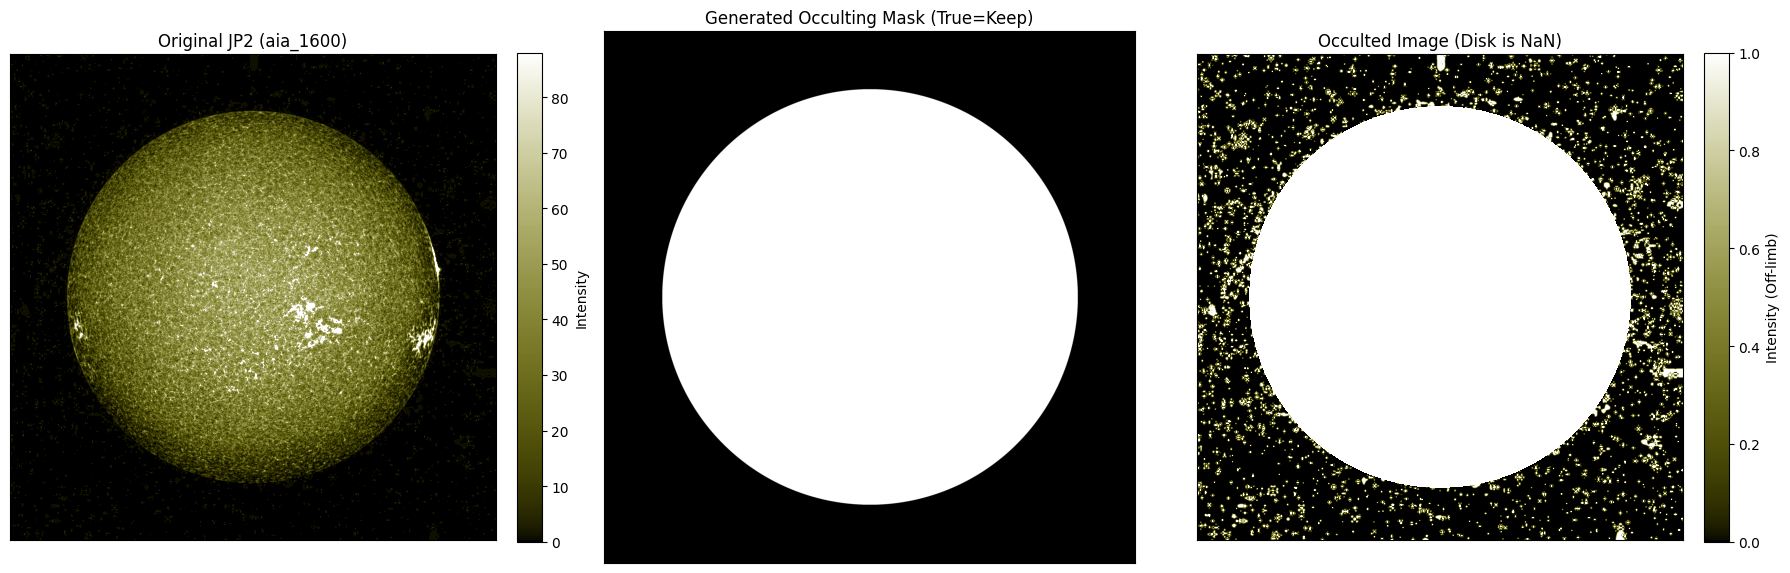

In [11]:
# --- *** NUEVA Función de Máscara de Ocultación para JP2 *** ---
def create_occulting_mask_jp2(data: np.ndarray, fixed_radius_pixels: int) -> np.ndarray:
    """Creates an occulting mask (hides solar disk) for JP2 images using a fixed radius."""
    if data is None:
        raise ValueError("Input data cannot be None for JP2 mask creation.")
    ny, nx = data.shape
    print(f"Creating JP2 occulting mask for image size {ny}x{nx} using fixed radius: {fixed_radius_pixels}")
    x_center, y_center = nx // 2, ny // 2 # Assume centered
    y, x = np.ogrid[:ny, :nx]
    distance_from_center = np.sqrt((x - x_center)**2 + (y - y_center)**2)
    # --- CAMBIO CLAVE: Invertir la condición ---
    # Selecciona píxeles FUERA del radio
    mask = distance_from_center > fixed_radius_pixels
    # ------------------------------------------
    print(f"  Generated JP2 occulting mask shape: {mask.shape}, Sum (True pixels): {np.sum(mask)}")
    return mask

# --- Notebook Execution (using simplified loader and OCCULTING mask) ---

# 1. Define Data Path
# <<< ¡¡¡ ASEGÚRATE DE QUE ESTA RUTA SEA CORRECTA !!! >>>
base_data_dir = '/home/alyonaivanova/personal/SOLAR/Data/sdo_jp2'
test_channel = 'aia_1600' # <<< Elige un canal para probar (1600 es bueno para ver fuera del limbo)
# test_channel = 'aia_131' # O prueba con otro
channel_dir = os.path.join(base_data_dir, test_channel)

# 2. Load Data using the Imageio-only function
jp2_data, _ = load_jp2_data_imageio(channel_dir) # Metadata no se usa

# 3. Create Occulting Mask (if data loaded)
jp2_mask = None
if jp2_data is not None:
    # --- *** LLAMAR A LA FUNCIÓN DE MÁSCARA DE OCULTACIÓN *** ---
    jp2_mask = create_occulting_mask_jp2(jp2_data, fixed_radius_pixels=1600)
    # ----------------------------------------------------------

# 4. Visualize
if jp2_data is not None and jp2_mask is not None:
    # Aplicar la máscara: Poner NaN donde la máscara es False (DENTRO del disco)
    masked_jp2_data = jp2_data.astype(float).copy() # Trabajar con copia float
    masked_jp2_data[~jp2_mask] = np.nan # Poner NaN DENTRO del disco solar (~jp2_mask es True adentro)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Determinar buenos límites de intensidad para mostrar (evitar extremos)
    # ¡IMPORTANTE! Calcular vmin/vmax de los datos enmascarados (solo la corona)
    # para mejorar el contraste fuera del disco.
    valid_pixels = masked_jp2_data[~np.isnan(masked_jp2_data)]
    if valid_pixels.size > 0:
        vmin = np.percentile(valid_pixels, 5)  # Ajustar percentiles si es necesario
        vmax = np.percentile(valid_pixels, 98) # para resaltar la corona
    else:
        vmin = np.percentile(jp2_data, 1) # Fallback a datos originales si no queda nada
        vmax = np.percentile(jp2_data, 99)


    # Mapa de color apropiado para el canal (si está disponible) o genérico
    cmap_name = f'sdoaia{test_channel.split("_")[1]}'
    try:
        plt.get_cmap(cmap_name)
    except ValueError:
        print(f"Colormap {cmap_name} not found, using 'gray'.")
        cmap_name = 'gray' # Usar 'gray' o 'hot' como fallback

    # Original Image
    im0 = axes[0].imshow(jp2_data, cmap=cmap_name, origin='lower',
                         vmin=np.percentile(jp2_data, 1), vmax=np.percentile(jp2_data, 99)) # Vmin/Vmax de la original
    axes[0].set_title(f"Original JP2 ({test_channel})")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Intensity")

    # Mask (True = fuera del disco)
    im1 = axes[1].imshow(jp2_mask, cmap='binary', origin='lower')
    axes[1].set_title("Generated Occulting Mask (True=Keep)") # Título actualizado

    # Masked Image (Disco oculto)
    im2 = axes[2].imshow(masked_jp2_data, cmap=cmap_name, origin='lower', vmin=vmin, vmax=vmax) # Vmin/Vmax ajustados
    axes[2].set_title("Occulted Image (Disk is NaN)") # Título actualizado
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="Intensity (Off-limb)")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

elif jp2_data is not None and jp2_mask is None:
    print("Data loaded, but occulting mask creation failed.")
    # Optionally plot just the loaded data
    plt.figure(figsize=(8, 8))
    plt.imshow(jp2_data, cmap='gray', origin='lower') # Fallback cmap
    plt.title(f"Loaded JP2 ({test_channel}) - Mask Failed")
    plt.colorbar()
    plt.show()
else:
    print("Failed to load JP2 data for testing.")